In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = "/Users/bhanuprasadh/Desktop/Employee Attrition Analysis/data/processed/employee_attrition_cleaned.csv"

df = pd.read_csv(DATA_PATH)

df.head()

Matplotlib is building the font cache; this may take a moment.


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


In [2]:
print("Shape:", df.shape)

Shape: (1470, 31)


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EnvironmentSatisfaction   1470 non-null   int64
 9   Gender                    1470 non-null   str  
 10  HourlyRate                1470 non-null   int64
 11  JobInvolvement            1470 non-null   int64
 12  JobLevel                  1470 non-null   int64
 13  JobRole                   1470 non-null   str  
 14  JobSatisfaction           1470 non-null   int64
 15

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.0,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.0,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.0,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.0,3.0,4.00,5.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.0,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.0,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.0,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.0,2.0,3.00,5.0
JobSatisfaction,1470.0,2.728571,1.102846,1.0,2.0,3.0,4.00,4.0
MonthlyIncome,1470.0,6502.931293,4707.956783,1009.0,2911.0,4919.0,8379.00,19999.0


In [5]:
categorical_columns = df.select_dtypes(
    include="object"
).columns.tolist()

numerical_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

print("Categorical:")
print(categorical_columns)

print("\nNumerical:")
print(numerical_columns)

Categorical:
['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Numerical:
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


/var/folders/96/y8pbmg3910s0kyyndlqxtt700000gn/T/ipykernel_18857/1159054929.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(


In [6]:
df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [7]:
df["Attrition"].value_counts(normalize=True) * 100

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

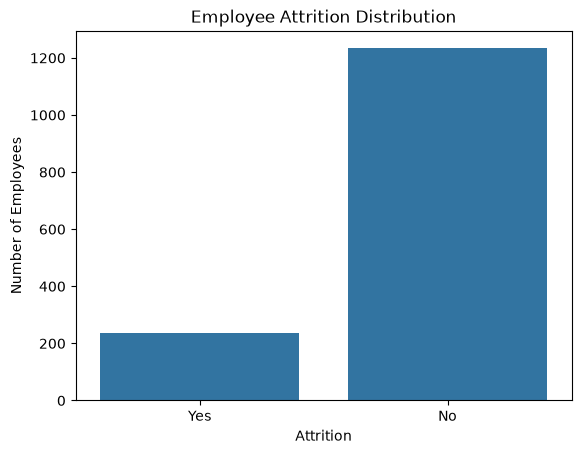

In [8]:
sns.countplot(data=df, x="Attrition")

plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")

plt.show()

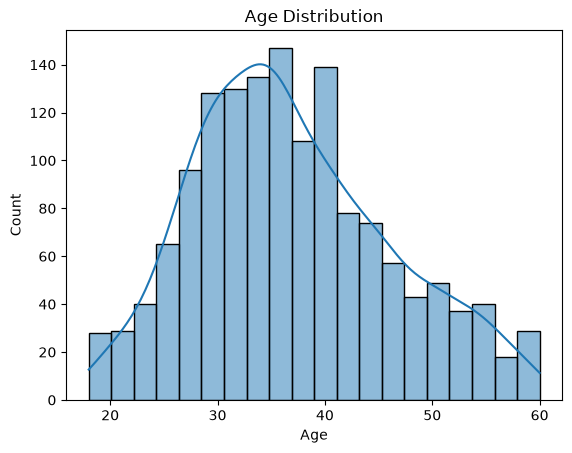

In [9]:
sns.histplot(
    data=df,
    x="Age",
    bins=20,
    kde=True
)

plt.title("Age Distribution")
plt.show()

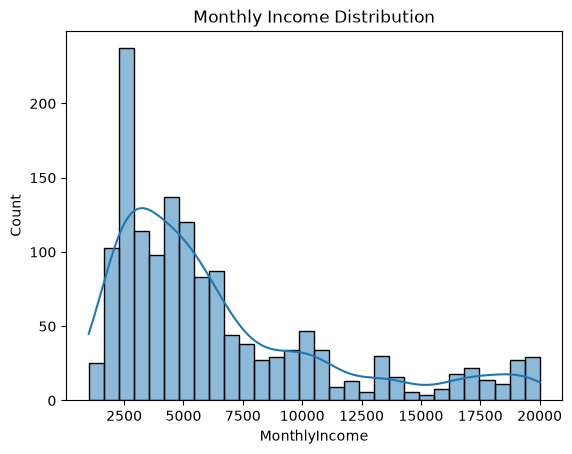

In [10]:
sns.histplot(
    data=df,
    x="MonthlyIncome",
    bins=30,
    kde=True
)

plt.title("Monthly Income Distribution")
plt.show()

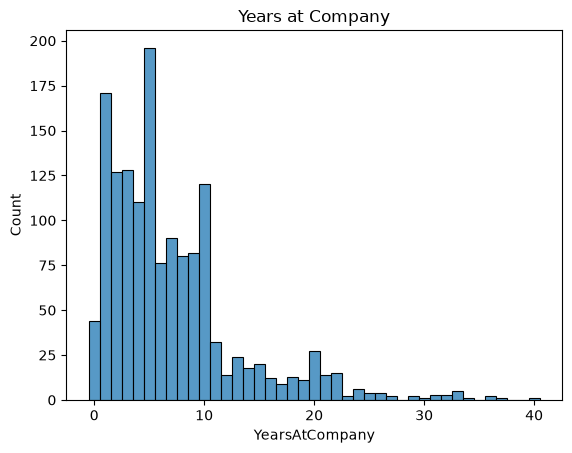

In [11]:
sns.histplot(
    data=df,
    x="YearsAtCompany",
    discrete=True
)

plt.title("Years at Company")
plt.show()

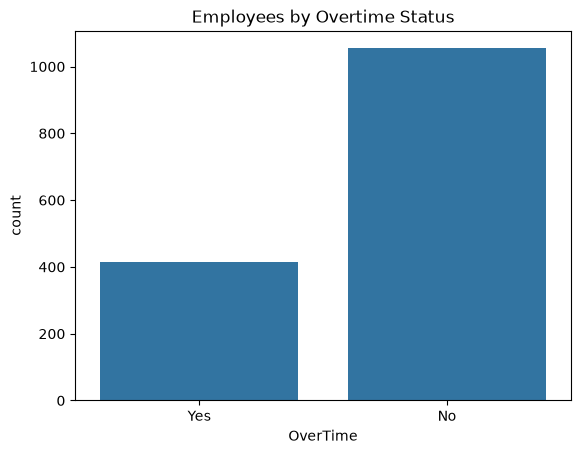

In [12]:
sns.countplot(
    data=df,
    x="OverTime"
)

plt.title("Employees by Overtime Status")
plt.show()

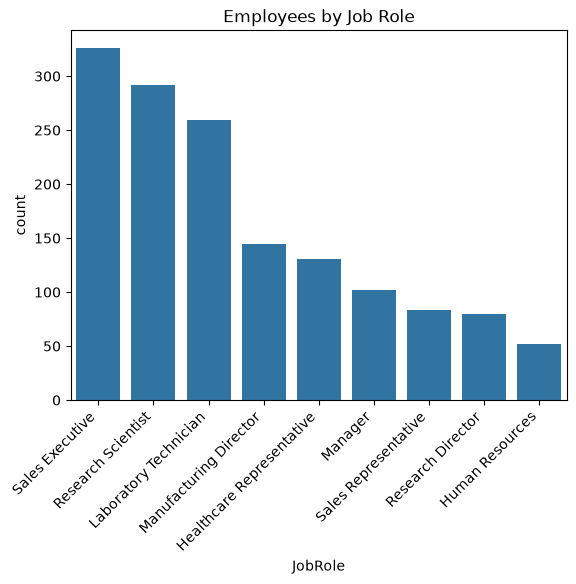

In [13]:
sns.countplot(
    data=df,
    x="JobRole"
)

plt.xticks(rotation=45, ha="right")
plt.title("Employees by Job Role")
plt.show()

In [14]:
pd.crosstab(
    df["OverTime"],
    df["Attrition"]
)

Attrition,No,Yes
OverTime,,
No,944,110
Yes,289,127


In [15]:
pd.crosstab(
    df["OverTime"],
    df["Attrition"],
    normalize="index"
) * 100

Attrition,No,Yes
OverTime,,
No,89.563567,10.436433
Yes,69.471154,30.528846


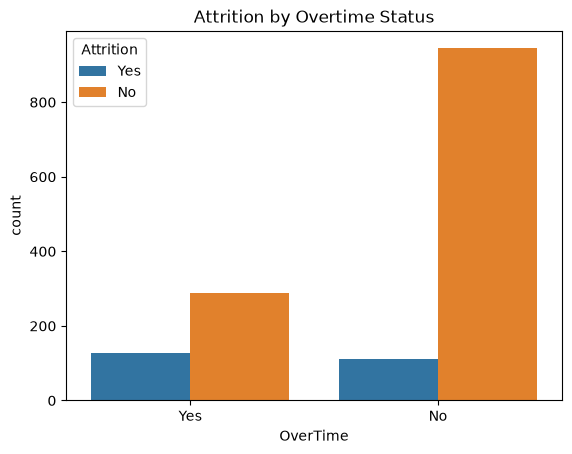

In [16]:
sns.countplot(
    data=df,
    x="OverTime",
    hue="Attrition"
)

plt.title("Attrition by Overtime Status")
plt.show()

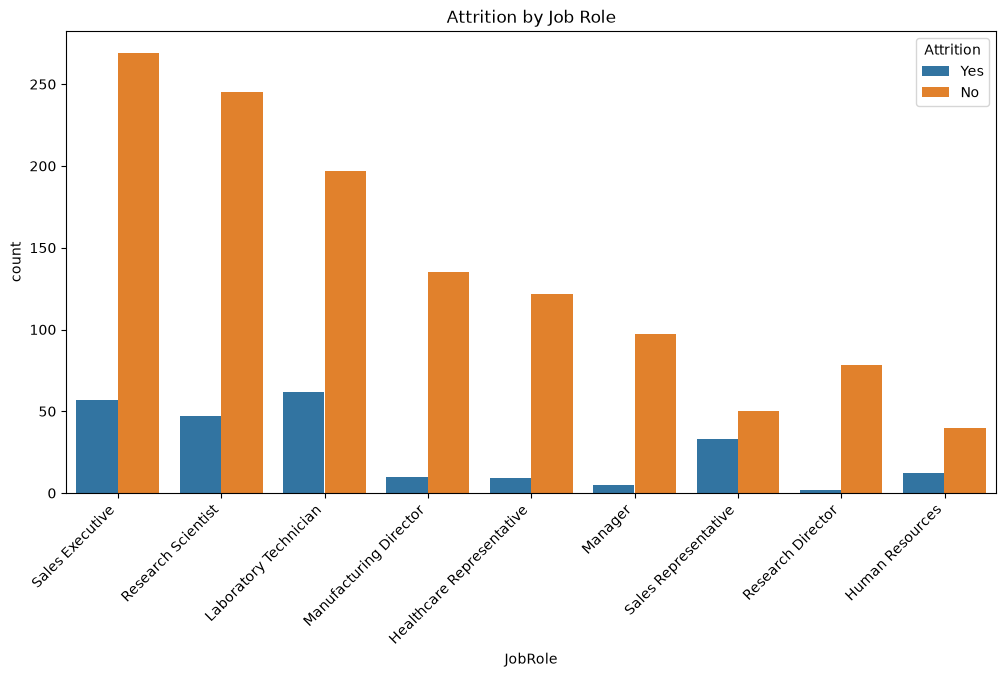

In [17]:
plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    x="JobRole",
    hue="Attrition"
)

plt.xticks(rotation=45, ha="right")
plt.title("Attrition by Job Role")

plt.show()

In [18]:
attrition_by_role = (
    df.groupby("JobRole")["Attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .sort_values(ascending=False)
)

attrition_by_role

JobRole
Sales Representative         39.759036
Laboratory Technician        23.938224
Human Resources              23.076923
Sales Executive              17.484663
Research Scientist           16.095890
Manufacturing Director        6.896552
Healthcare Representative     6.870229
Manager                       4.901961
Research Director             2.500000
Name: Attrition, dtype: float64

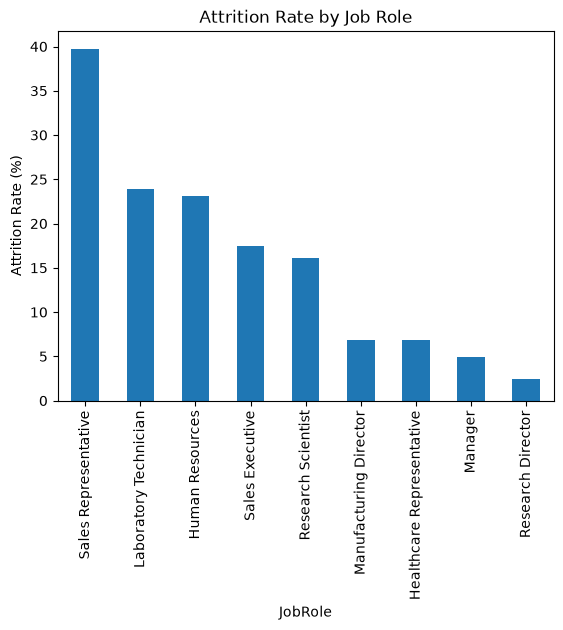

In [19]:
attrition_by_role.plot(kind="bar")

plt.ylabel("Attrition Rate (%)")
plt.title("Attrition Rate by Job Role")

plt.show()

In [20]:
department_attrition = (
    df.groupby("Department")["Attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
)

department_attrition

Department
Human Resources           19.047619
Research & Development    13.839750
Sales                     20.627803
Name: Attrition, dtype: float64

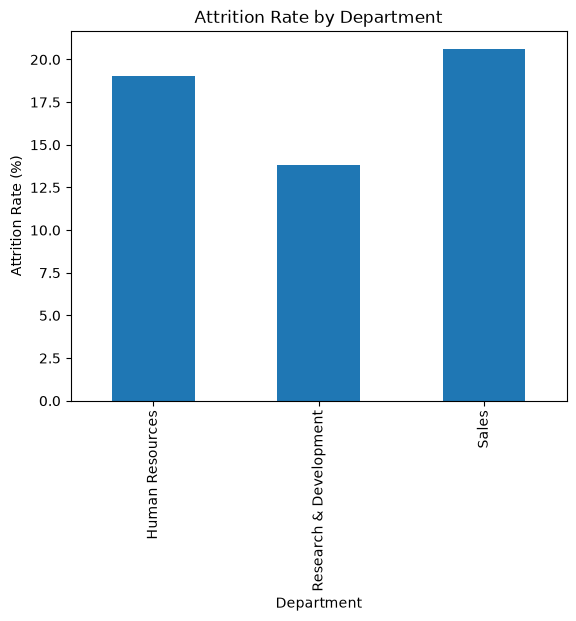

In [21]:
department_attrition.plot(kind="bar")

plt.ylabel("Attrition Rate (%)")
plt.title("Attrition Rate by Department")

plt.show()

In [22]:
travel_attrition = (
    df.groupby("BusinessTravel")["Attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
)

travel_attrition

BusinessTravel
Non-Travel            8.000000
Travel_Frequently    24.909747
Travel_Rarely        14.956855
Name: Attrition, dtype: float64

In [23]:
travel_attrition = (
    df.groupby("BusinessTravel")["Attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
)

travel_attrition

BusinessTravel
Non-Travel            8.000000
Travel_Frequently    24.909747
Travel_Rarely        14.956855
Name: Attrition, dtype: float64

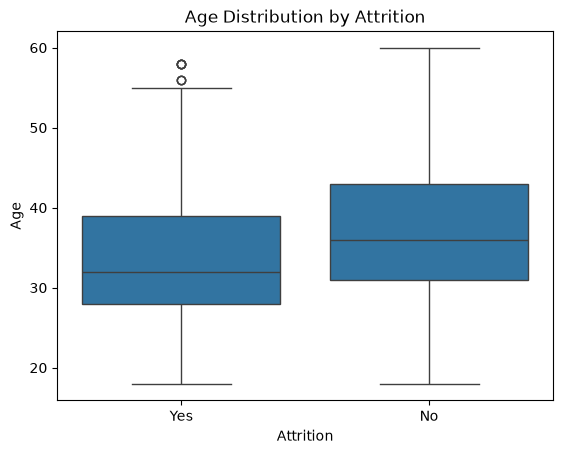

In [24]:
sns.boxplot(
    data=df,
    x="Attrition",
    y="Age"
)

plt.title("Age Distribution by Attrition")
plt.show()

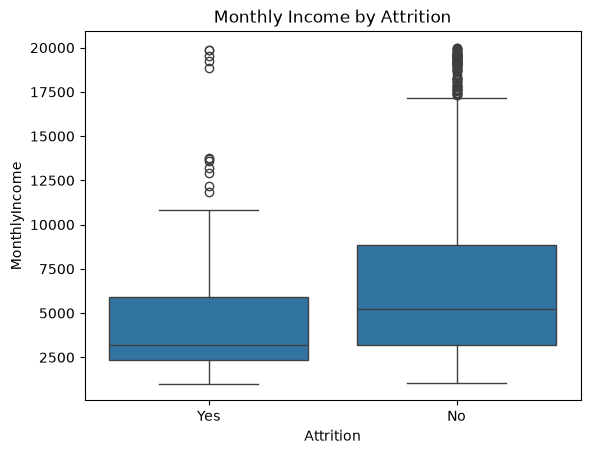

In [25]:
sns.boxplot(
    data=df,
    x="Attrition",
    y="MonthlyIncome"
)

plt.title("Monthly Income by Attrition")
plt.show()

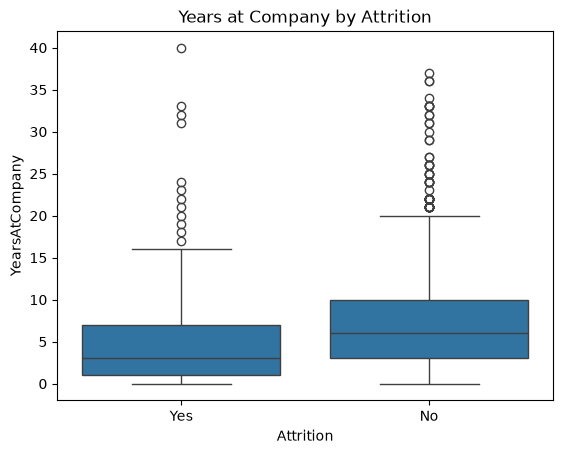

In [26]:
sns.boxplot(
    data=df,
    x="Attrition",
    y="YearsAtCompany"
)

plt.title("Years at Company by Attrition")
plt.show()

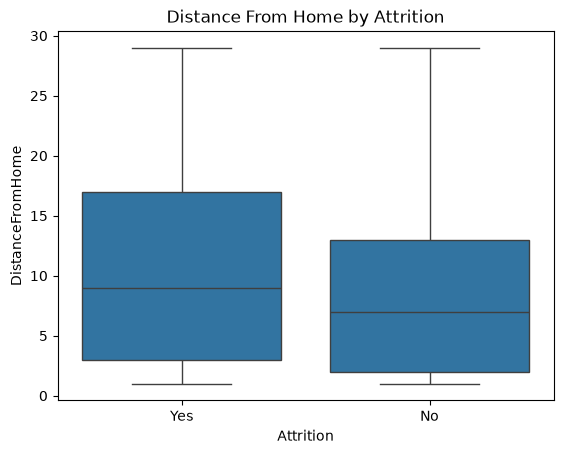

In [27]:
sns.boxplot(
    data=df,
    x="Attrition",
    y="DistanceFromHome"
)

plt.title("Distance From Home by Attrition")
plt.show()

In [28]:
pd.crosstab(
    df["JobSatisfaction"],
    df["Attrition"],
    normalize="index"
) * 100

Attrition,No,Yes
JobSatisfaction,,
1,77.162630,22.837370
2,83.571429,16.428571
3,83.484163,16.515837
4,88.671024,11.328976


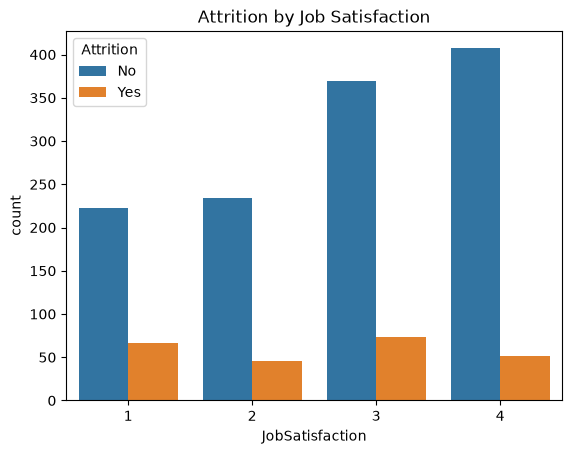

In [29]:
sns.countplot(
    data=df,
    x="JobSatisfaction",
    hue="Attrition"
)

plt.title("Attrition by Job Satisfaction")
plt.show()

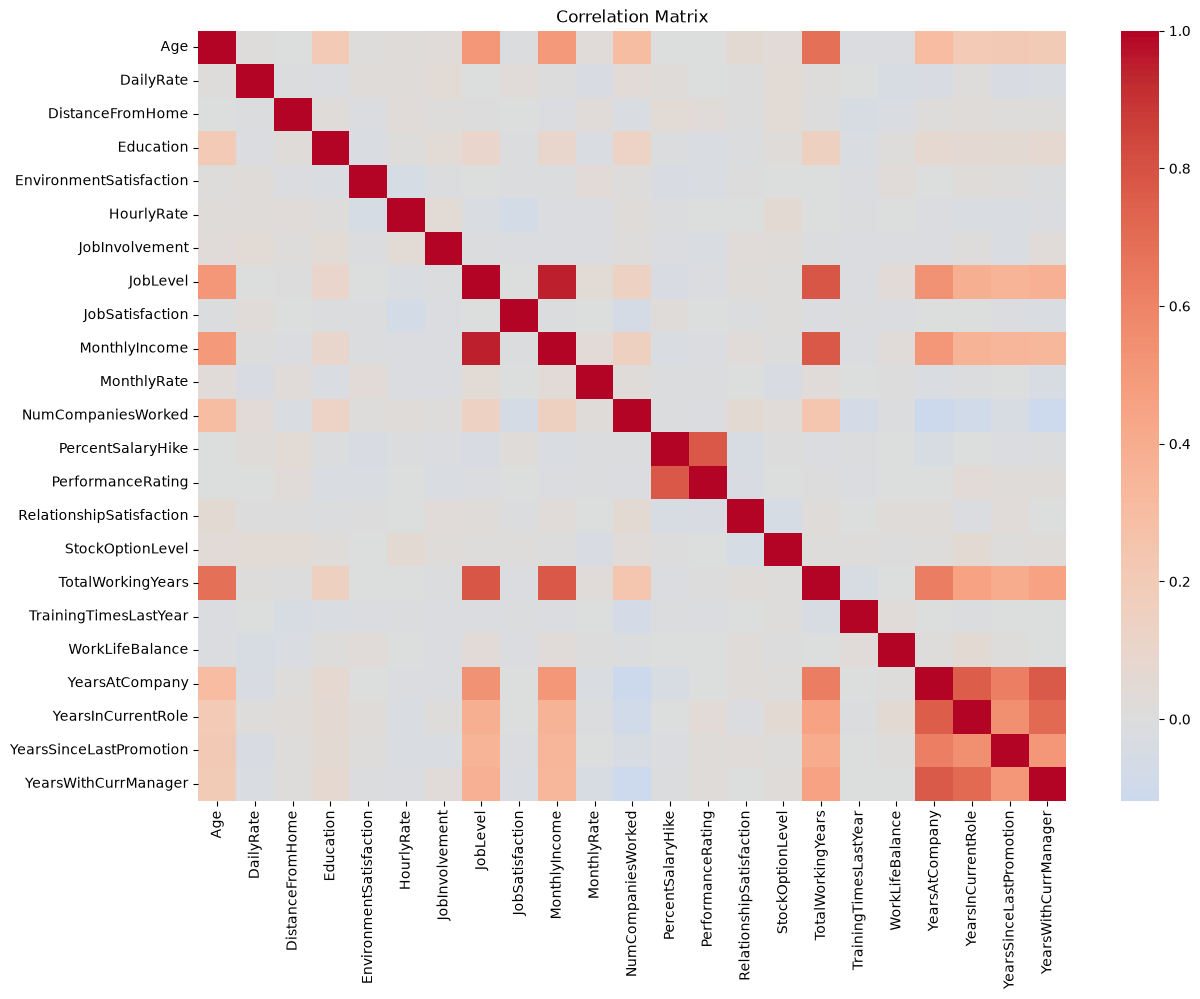

In [30]:
plt.figure(figsize=(14, 10))

correlation = df.select_dtypes(
    include=np.number
).corr()

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.show()

In [31]:
pd.crosstab(
    [df["JobRole"], df["OverTime"]],
    df["Attrition"],
    normalize="index"
) * 100

Attrition                                  No        Yes
JobRole                   OverTime                      
Healthcare Representative No        92.553191   7.446809
                          Yes       94.594595   5.405405
Human Resources           No        82.051282  17.948718
                          Yes       61.538462  38.461538
Laboratory Technician     No        84.263959  15.736041
                          Yes       50.000000  50.000000
Manager                   No        98.666667   1.333333
                          Yes       85.185185  14.814815
Manufacturing Director    No        94.339623   5.660377
                          Yes       89.743590  10.256410
Research Director         No        98.245614   1.754386
                          Yes       95.652174   4.347826
Research Scientist        No        92.820513   7.179487
                          Yes       65.979381  34.020619
Sales Executive           No        88.793103  11.206897
                          Yes       67.021277  32.978723
Sales Representative      No        71.186441  28.813559
                          Yes       33.333333  66.666667

In [32]:
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 25, 35, 45, 55, 100],
    labels=[
        "<=25",
        "26-35",
        "36-45",
        "46-55",
        "56+"
    ]
)

In [33]:
df.groupby("AgeGroup", observed=True)["Attrition"].apply(
    lambda x: (x == "Yes").mean() * 100
)

AgeGroup
<=25     35.772358
26-35    19.141914
36-45     9.188034
46-55    11.504425
56+      17.021277
Name: Attrition, dtype: float64